In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random


# 展示中文
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False     # 正常显示负号


### 1. Matplotlib入门案例_ 绘制北京近一周的气温折线图

In [ ]:
# 回顾可视化的3个步骤：1.创建画布 2. 准备数据(x轴，Y轴)， 3.具体绘制
# 1. 创建画布
plt.figure(figsize=(10, 5))
# 2. 准备数据
plt.plot([1, 2, 3, 4, 5, 6, 7], [15, 11, 19, 5, 21, 28 ,22])

plt.grid()

plt.show()

## 2. Matplotlib入门案例_ 绘制标准折线图

In [ ]:
# 需求：画出某个城市11点-12点1小时内每分钟的温度变化折线图，温度范围15度~18度

### 2.1 准备数据并绘制初始折线图

In [ ]:
# 1. 准备X轴(60分钟) 和 Y轴(每分钟的温度)的数据
x=range(60) # x的值： 0~60 包左不包右
y_bj = [random.uniform(15, 18) for i in x]
# print(y_bj)
# 2. 创建画布
plt.figure(figsize=(10, 5), dpi=80)
# 3. 绘制折线图
plt.plot(x, y_bj, color='red')
# 4. 具体的绘制动作
plt.show()

### 2.2 添加x轴，Y轴刻度信息,网格,标题，X轴标签，Y轴标签，保存图片

In [ ]:
# 涉及到的函数：plt.xticks(x, **kwargs), plt.yticks(y, **kwargs)
x=range(60) # x的值： 0~60 包左不包右
y_bj = [random.uniform(15, 18) for i in x]

# print(y_bj)
# 2. 创建画布
plt.figure(figsize=(10, 5), dpi=80)

# 3. 绘制折线图
plt.plot(x, y_bj, color='red')

# 4. 添加x轴，Y轴刻度信息
# 4.1 准备X轴 刻度信息
x_ticks_label = [f'11点{i}分' for i in x]
y_ticks = range(40)
# 4.2 设置Y轴/X轴刻度信息
plt.yticks(y_ticks[::5])
plt.xticks(x[::5], x_ticks_label[::5]) # 参1：X轴刻度值，参数2：X轴刻度值对应的标签

# 5. 添加网格
plt.grid(linestyle='--', alpha=0.5)

# 6. 添加标题
plt.title('北京11点-12点1小时内每分钟的温度变化折线图', fontsize=20)
plt.xlabel('时间', fontsize=12)
plt.ylabel('温度', fontsize=12)

# 7.图标保存
plt.savefig('./resources/bj_temp.png')

# 8. 具体的绘制动作
plt.show()  # 要放到最后

## 3. 在一个画布中多次plot()绘制折线图

In [ ]:
# 需求：在一个画布中，绘制两个城市的 温度图
# 1. 准备数据
x=range(60)
y_bj = [random.uniform(5, 18) for i in x]
y_sh = [random.uniform(10, 15) for i in x]

# 2. 创建画布
plt.figure(figsize=(20, 8), dpi=80)

# 3. 绘制折线图
# 3.1 绘制2个折线图
plt.plot(x, y_bj, color='red', label='北京')
plt.plot(x, y_sh, color='green', label='上海', linestyle='--')
# 3.2 创建X轴的刻度值，以及 X轴，Y轴的刻度范围
x_ticks_label = [f'11点{i}分' for i in x]
y_ticks = range(20)
plt.xticks(x[::5], x_ticks_label[::5])
plt.yticks(y_ticks[::2])

# 3.3 标题，X轴，Y轴标签
plt.title('北京上海11点-12点1小时内每分钟的温度变化折线图', fontsize=20)
plt.xlabel('时间', fontsize=12)
plt.ylabel('温度', fontsize=12)
# 3.4 网格
plt.grid(linestyle='--', alpha=0.5)
# 3.5 添加图例
plt.legend(loc=0) # 0 ~10

# 4. 绘制画布
plt.show()

## 4. 一个画布，多个坐标轴 --> 面向对象绘图方式

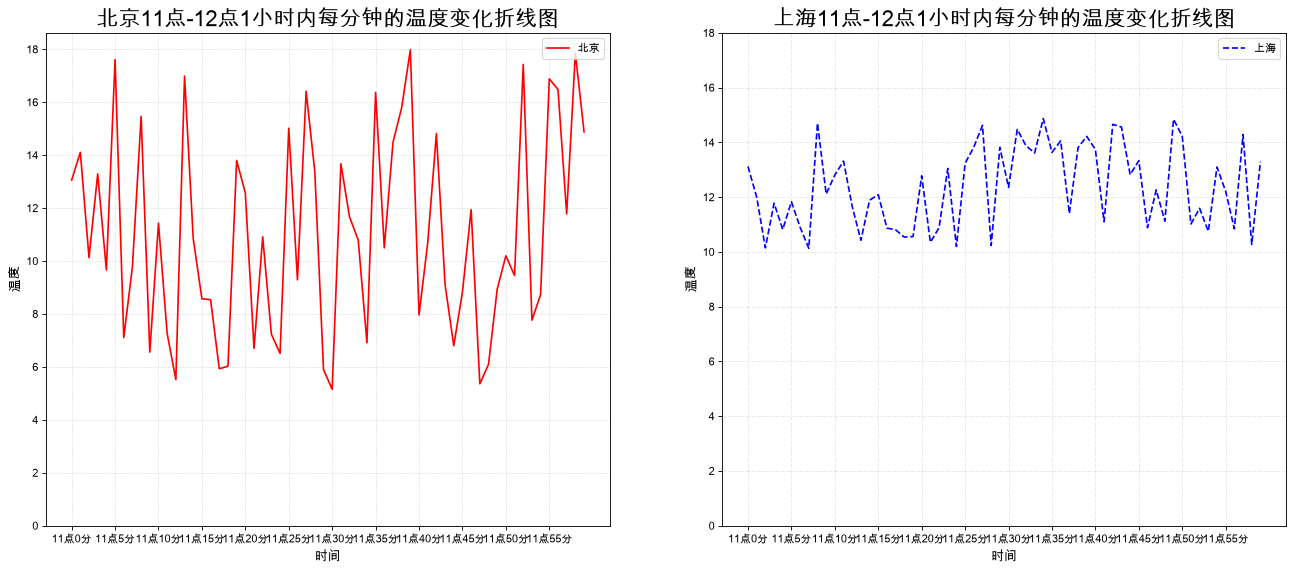

In [62]:
# 需求：在一个画布中，绘制两个城市的 温度图
# 1. 准备数据
x=range(60)
y_bj = [random.uniform(5, 18) for i in x]
y_sh = [random.uniform(10, 15) for i in x]

# 2. 创建画布
# plt.figure(figsize=(20, 8), dpi=80)
# 以元祖的形式返回结果, 即：（画布对象，坐标轴对象）
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8), dpi=80)

# 3. 绘制折线图
# 3.1 绘制2个折线图
axes[0].plot(x, y_bj, color='red', label='北京')
axes[1].plot(x, y_sh, color='blue', label='上海', linestyle='--')
# 3.2 创建X轴的刻度值，以及 X轴，Y轴的刻度范围
x_ticks_label = [f'11点{i}分' for i in x]
y_ticks = range(20)
# plt.xticks(x[::5], x_ticks_label[::5])
# plt.yticks(y_ticks[::2])
# 设置左边坐标轴(即axes[0])
axes[0].set_xticks(x[::5], x_ticks_label[::5])
axes[0].set_yticks(y_ticks[::2])
# 设置右边坐标轴(即axes[1])
axes[1].set_xticks(x[::5])  # step1： 设置X轴刻度值
axes[1].set_xticklabels(x_ticks_label[::5])  # step2： 设置X轴刻度值对应的标签
axes[1].set_yticks(y_ticks[::2])

# 3.3 标题，X轴，Y轴标签
# plt.title('北京上海11点-12点1小时内每分钟的温度变化折线图', fontsize=20)
# plt.xlabel('时间', fontsize=12)
# plt.ylabel('温度', fontsize=12)
# 设置左边坐标轴(即axes[0])
axes[0].set_title('北京11点-12点1小时内每分钟的温度变化折线图', fontsize=20)
axes[0].set_xlabel('时间', fontsize=12)
axes[0].set_ylabel('温度', fontsize=12)
# 设置右边坐标轴(即axes[1])
axes[1].set_title('上海11点-12点1小时内每分钟的温度变化折线图', fontsize=20)
axes[1].set_xlabel('时间', fontsize=12)
axes[1].set_ylabel('温度', fontsize=12)
# 3.4 网格
# plt.grid(linestyle='--', alpha=0.5)
axes[0].grid(linestyle='--', alpha=0.5)
axes[1].grid(linestyle='-.', alpha=0.5)
# 3.5 添加图例
# plt.legend(loc=0) # 0 ~10
axes[0].legend(loc=1)
axes[1].legend(loc=1)
# 5. 添加图片
plt.savefig('./resources/bj_sh_temp.png')
# 4. 绘制画布
plt.show()

## 5. 简单折线图

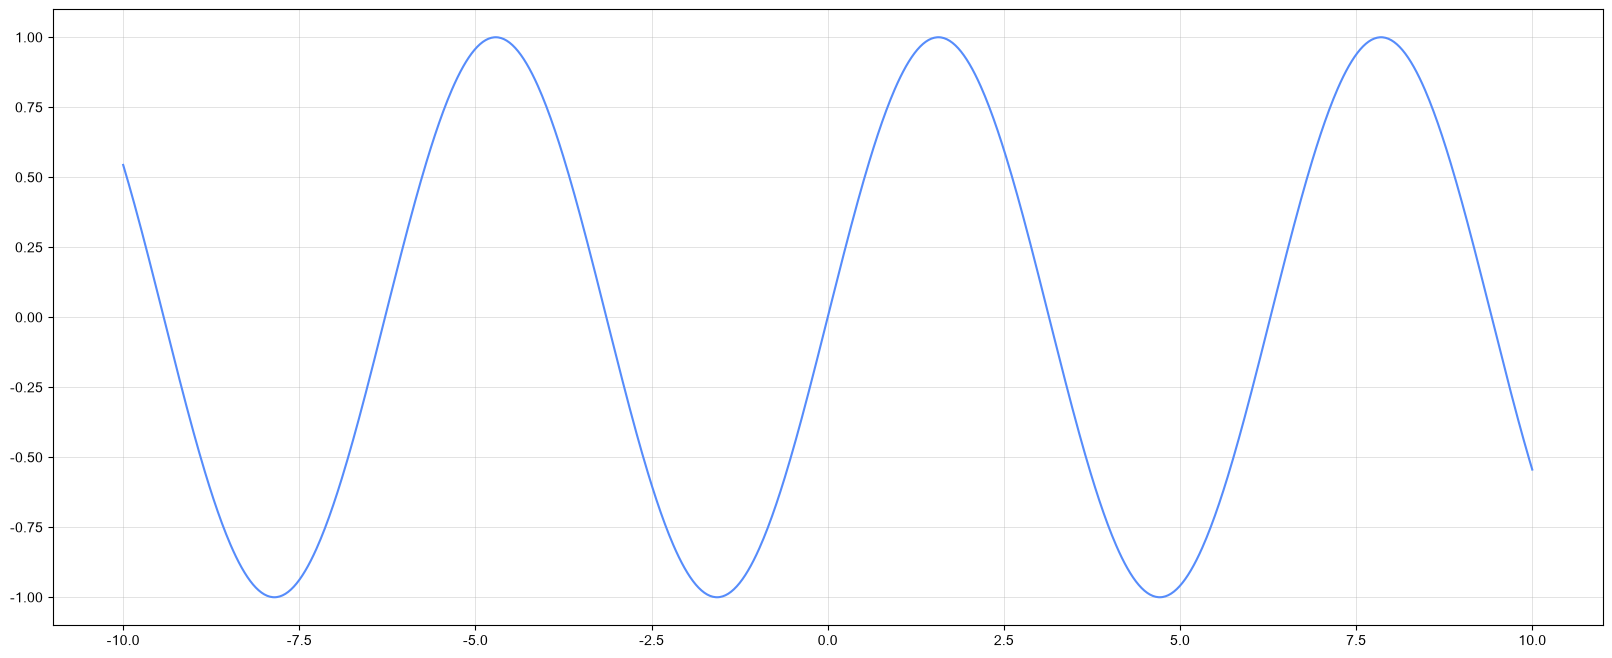

In [63]:
# 准备数据
x = np.linspace(-10, 10, 1000) # 等差数列
y = np.sin(x)
# 创建画布
plt.figure(figsize=(20, 8), dpi=100)
# 绘制图像
plt.plot(x, y)
plt.grid()
# 显示
plt.show()

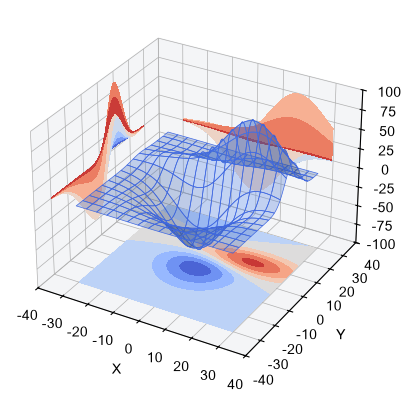

In [66]:
from mpl_toolkits.mplot3d import axes3d

ax = plt.figure().add_subplot(projection='3d')
X, Y, Z = axes3d.get_test_data(0.05)

# Plot the 3D surface
ax.plot_surface(X, Y, Z, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

# Plot projections of the contours for each dimension.  By choosing offsets
# that match the appropriate axes limits, the projected contours will sit on
# the 'walls' of the graph
ax.contourf(X, Y, Z, zdir='z', offset=-100, cmap='coolwarm')
ax.contourf(X, Y, Z, zdir='x', offset=-40, cmap='coolwarm')
ax.contourf(X, Y, Z, zdir='y', offset=40, cmap='coolwarm')

ax.set(xlim=(-40, 40), ylim=(-40, 40), zlim=(-100, 100),
       xlabel='X', ylabel='Y', zlabel='Z')

plt.show()

## 6. Matplotlib绘制其他常用图形

### 6.1 柱状图bar() ->适用于对比，统计...

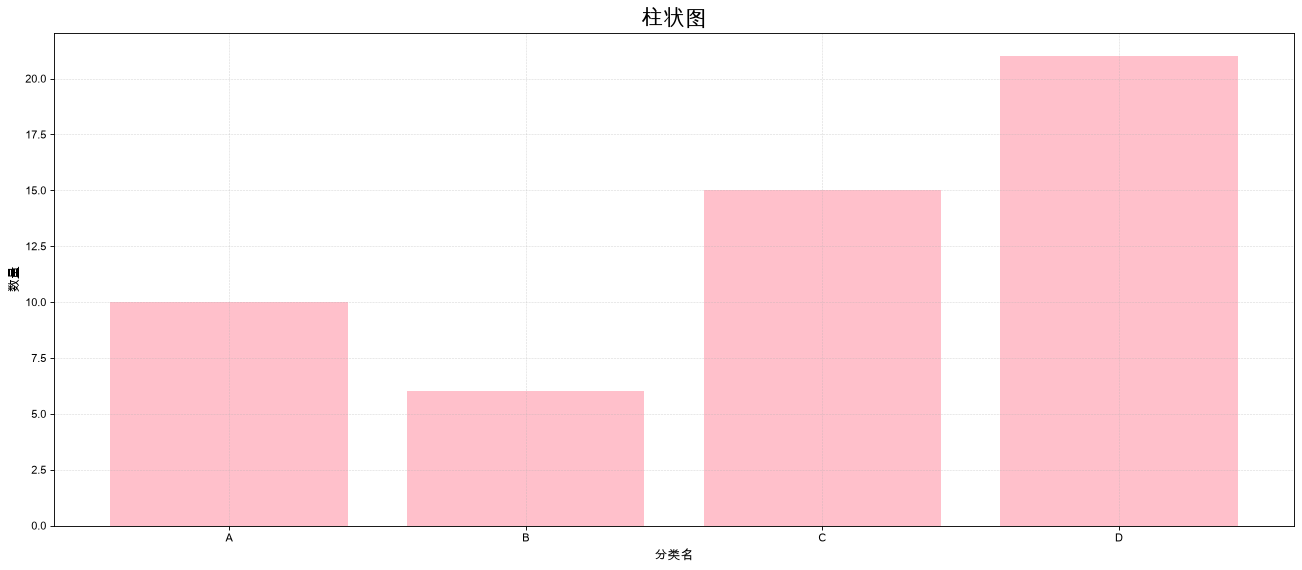

In [74]:
# 准备数据
x = ['A', 'B', 'C', 'D']
y = [10, 6, 15, 21]

# 创建画布
plt.figure(figsize=(20, 8), dpi=80)

# 绘制
plt.bar(x, y, color='pink') # 柱状图
# 网格
plt.grid(linestyle='--',alpha=0.5)
# 标题，X轴，Y轴标签
plt.title('柱状图', fontsize=20)
plt.xlabel('分类名', fontsize=12)
plt.ylabel('数量', fontsize=12)

# 显示
plt.show()

### 6.2 直方图 hist() --->适用于  连续的数据的 分布， 统计...

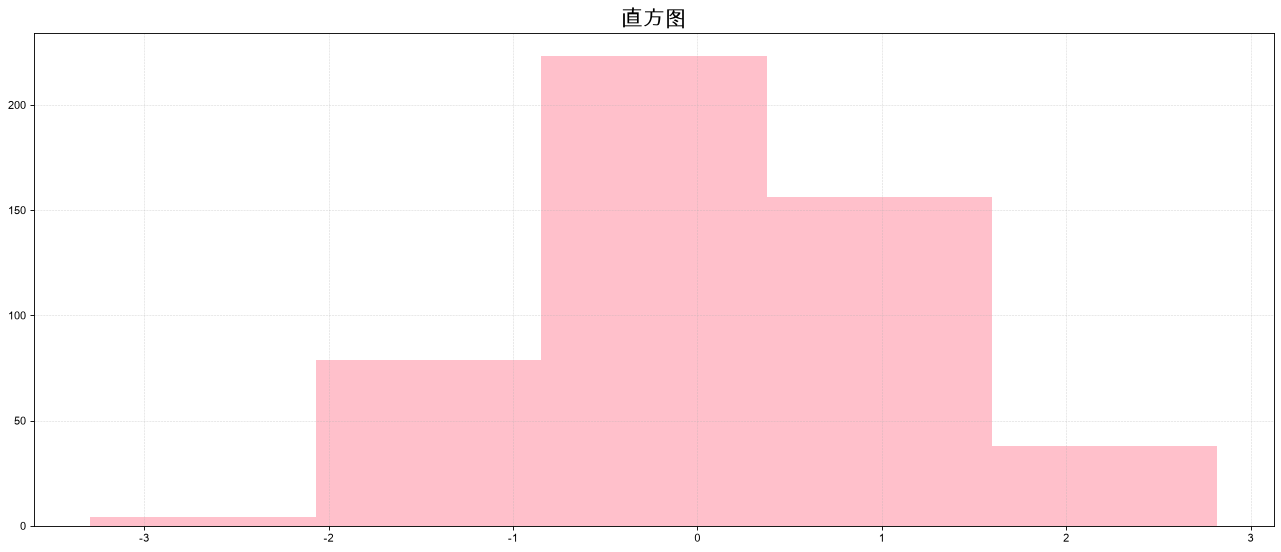

In [78]:
# 准备数据
data = np.random.randn(500)  # 生成500个随机数 ---> 符合正态分布的

# 创建画布
plt.figure(figsize=(20, 8), dpi=80)

# 绘制
plt.hist(data, bins=5, color='pink') # 直方图  5个区间
# 网格
plt.grid(linestyle='--',alpha=0.5)
# 标题，X轴，Y轴标签
plt.title('直方图', fontsize=20)

# 显示
plt.show()

### 6.3 饼图 pie() ---> 适用于 比例，占比...

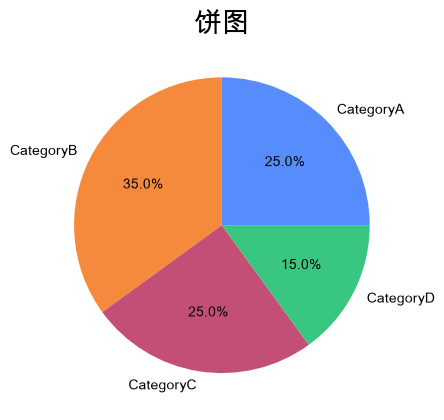

In [84]:
# 准备数据
size = [25, 35, 25, 15]
labels = ['CategoryA', 'CategoryB', 'CategoryC', 'CategoryD']

# 创建画布
# plt.figure(figsize=(20, 8), dpi=80)

# 绘制
plt.pie(size, labels=labels, autopct='%1.1f%%')  # 饼图

# 标题，X轴，Y轴标签
plt.title('饼图', fontsize=20)

# 显示
plt.show()

### 6.4 散点图 scatter() ---> 适用于 三点数据的统计，或者统计两列值之间的关系...

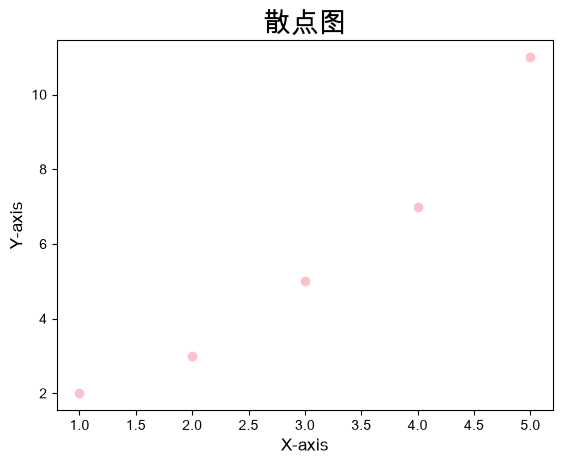

In [83]:
# 准备数据
x = [1, 2, 3, 4,5]
y = [2, 3, 5, 7, 11]

# 创建画布
# plt.figure(figsize=(20, 8), dpi=80)

# 绘制
plt.scatter(x, y, color='pink')  # 散点图

# 标题，X轴，Y轴标签
plt.title('散点图', fontsize=20)
plt.xlabel('X-axis', fontsize=12)
plt.ylabel('Y-axis', fontsize=12)

# 显示
plt.show()